In [16]:
# from ansys.aedt.core import Desktop
# from ansys.aedt.core.maxwell import Maxwell2d
# from ansys.aedt.core.generic.grpc_plugin_dll_class import AedtPropServer
# DT = Desktop(version="2024.2", non_graphical=False, student_version=False, new_desktop=False)

# M2D: AedtPropServer = DT.active_design()
# M2D: Maxwell2d = Maxwell2d(design="test2")
# # M2D.delete_design("linear_motor_3slot_2D")
# print(DT.project_list())

In [17]:
import pandas as pd
import numpy as np
import os
import ansys.aedt.core
import math
import shutil
import time
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from dataclasses import dataclass, field
from os.path import join
import math
from ansys.aedt.core import Desktop
from ansys.aedt.core.maxwell import Maxwell2d
from ansys.aedt.core.generic.grpc_plugin_dll_class import AedtPropServer
import subprocess
import sys
import psutil
from typing import List

def get_ansysedt_pids() -> List[int]:
    """
    현재 시스템에서 실행 중인 'ansysedt.exe' 프로세스의 PID를 반환합니다.
    
    Returns:
        List[int]: ansysedt.exe 프로세스의 PID 리스트.
    """
    pids = []
    # 'name' 정보를 포함하여 반복
    for proc in psutil.process_iter(['name']):
        try:
            name = proc.info['name']
            if name and name.lower() == 'ansysedt.exe':
                pids.append(proc.pid)
        except (psutil.NoSuchProcess, psutil.AccessDenied, psutil.ZombieProcess):
            # 프로세스가 존재하지 않거나 접근 권한이 없는 경우 건너뜁니다.
            continue
    return pids

@dataclass
class SimulationParameters:
    # 주요 파라미터 (기본 값)
    depth: float = 40               # 모델의 적층깊이
    num_pole: int = 10              # 자석의 갯수
    m_w: float = 20                 # 자석의 너비
    m_h: float = 5                  # 자석의 높이
    my_th: float = 15               # 자석판의 두께
    num_slot: int = 3               # 슬롯 개수
    airgap: float = 1               # 공극 길이
    t_w: float = 6                  # teeth 폭
    J_rated: float = 3              # 코일 영역 전류밀도
    cy_th: float = 15               # 요크 두께
    c_w: float = 5                  # 코일의 너비
    c_h: float = 15                 # 코일의 높이

    turn_c: int = 100               # 코일의 턴수
    gamma: float = 0                # 전류각 미스매치 (0이면 0)
    freq_elec: float = 10           # 전기각 주파수

    current_b: float = 0            # 나머지 전류 설정
    current_c: float = 0

    movement: bool = True           # True: +x방향 이동, False: -x방향 이동

    # 아래 필드는 다른 파라미터로부터 계산됨 (초기화 시 제외: init=False)
    gap_w: float = field(init=False)       # 자석 사이의 공간
    t_g: float = field(init=False)           # teeth 간격
    t_h: float = field(init=False)           # 치의 높이
    my_w: float = field(init=False)          # 자석판의 너비
    area: float = field(init=False)          # terminal 면적
    current_rated: float = field(init=False) # 상 정격 전류
    theta_elec_offset: float = field(init=False)  # 전기각 오프셋
    current_a: str = field(init=False)       # current expression (string)
    veolcity_stator: float = field(init=False)    # 1주기 속도 (m/s)

    def __post_init__(self):
        # 종속 파라미터 계산
        self.gap_w = self.m_w * 0.3
        self.t_g = (52 / 3 - self.t_w) / 2
        self.t_h = self.c_h                 # 치의 높이는 코일의 높이와 동일
        self.my_w = (self.m_w * self.num_pole + self.gap_w * (self.num_pole - 1)) / 3 * 4
        self.area = self.c_w * self.c_h
        self.current_rated = self.J_rated * self.area / self.turn_c
        self.theta_elec_offset = math.pi / 2 + self.gamma
        self.current_a = f"{self.current_rated}*cos(2*pi*{self.freq_elec}*Time + {self.theta_elec_offset})"
        self.veolcity_stator = 2 * (self.m_w + self.gap_w) / 1000 / (1 / self.freq_elec)

    def update_parameter(self, param_name: str, value):
        """
        주어진 파라미터 이름(param_name)의 값을 value로 변경하고, 
        __post_init__를 호출하여 종속 파라미터들을 재계산합니다.
        """
        if hasattr(self, param_name):
            setattr(self, param_name, value)
            self.__post_init__()
        else:
            raise ValueError(f"No parameter named {param_name}")

    def __str__(self):
        params = vars(self)
        return "\n".join(f"{key}: {value}" for key, value in params.items())

    def set_params(self, M2D:Maxwell2d) -> None:
            """
            각 파라미터를 대입
            """
            M2D["depth"] = f"{self.depth}mm"
            M2D["num_pole"] = f"{self.num_pole}"
            M2D["m_w"] = f"{self.m_w}mm"
            M2D["m_h"] = f"{self.m_h}mm"
            M2D["gap_w"] = f"{self.gap_w}mm"
            M2D["my_th"] = f"{self.my_th}mm"
            M2D["num_slot"] = f"{self.num_slot}"
            M2D["airgap"] = f"{self.airgap}mm"
            M2D["t_w"] = f"{self.t_w}mm"
            M2D["t_g"] = f"{self.t_g}mm"
            M2D["J_rated"] = f"{self.J_rated}"
            M2D["cy_th"] = f"{self.cy_th}mm"
            M2D["c_w"] = f"{self.c_w}mm"
            M2D["c_h"] = f"{self.c_h}mm"
            M2D["t_h"] = f"{self.t_h}mm"
            M2D["my_w"] = f"{self.my_w}mm"
            M2D["turn_c"] = f"{self.turn_c}"
            M2D["current_rated"] = f"{self.current_rated}"
            M2D["gamma"] = f"{self.gamma}"
            M2D["theta_elec_offset"] = f"{self.theta_elec_offset}"
            M2D["freq_elec"] = f"{self.freq_elec}"

class HW4:
    def __init__(self):
        pass

    def init_to_setup(
            self,
            p_name,
            desi_name,
            aedt_process_id,
            new_desktop=False,
            simparm:SimulationParameters = None
        ):
        proj_name = p_name
        DT = Desktop(
            version="2024.2", non_graphical=False, student_version=False, 
            new_desktop=new_desktop, aedt_process_id=aedt_process_id)
        # DT.design_list()
        # Option to automatically save at regular intervals
        # release it because The simulation is running on a script basis 
        DT.disable_autosave()
        if proj_name in  DT.project_list():
            proj_name = f"{proj_name}_n"
        
        # solution type
        sol_type = "Transient"
        # DT.save_project(project_name=proj_name)
        M2D = Maxwell2d(design="tmp", solution_type=sol_type)
        # if M2D:
        #     M2D = Maxwell2d(design=M2D.GetName())
        # else:
        #     M2D = 
        # M2D:Maxwell2d
        if len(DT.project_list())!=1:
            for i in DT.project_list():
                if i!=proj_name:
                    M2D.delete_project(i)
        if len(DT.design_list())!=1:       
            for i in DT.design_list():
                if i!="tmp":
                    M2D.delete_design(i)

        # creating maxwell3D design object
        # write solution type and whether you are using a student license
        # 처음 design 객체를 생성하면 새로운 project와 함께 생성되고, project와 design은 임의의 이름을 가짐

        M2D = Maxwell2d(solution_type=sol_type, student_version=False)
        M2D.autosave_disable()
        # ansys 레코딩 코드를 사용하기 위한 odesign 객체
        ## Project 폴더 만들기 ##

        # project name
        # change the name to what you want
        
        # path of project directory
        from os.path import join
        dir = join(os.getcwd(), proj_name)
        # dir = os.getcwd() + f"\\{proj_name}"
        print(dir)

        # # project 폴더 생성
        # # 실행 전 이전 폴더 삭제 필요
        if not os.path.exists(dir):
            os.mkdir(dir)

        # the name of maxwell3D design object
        # desi_name = "linear_motor_3slot_2D"
        ## Project 저장하고, Design 이름 설정 ##
        # M2D.autosave_disable()
        # design 객체가 존재하는 project 객체
        proj = M2D.oproject

        # # project 저장
        projPath = join(dir, f"{proj_name}.aedt")
        proj.SaveAs(projPath, True)
        # proj.SaveAs(f"{dir}\\{proj_name}.aedt", True)

        # design을 원하는 이름으로 변경
        M2D.rename_design(desi_name, save=False)
        for i in DT.design_list():
            if i!=desi_name:
                M2D.delete_design(i)

        M2D.save_project(projPath, overwrite=True)
        simparm.set_params(M2D)
        ## Analyze Setup 설정 ##

        # model depth 설정
        M2D.model_depth = "depth"
        
        oDesign = M2D.odesign
        self.DT, self.M2D, self.oDesign \
        = DT, M2D, oDesign

        oModule = oDesign.GetModule("AnalysisSetup")
        oModule.InsertSetup("Transient", 
            [
                "NAME:Setup1",
                "Enabled:="		, True,
                [
                    "NAME:MeshLink",
                    "ImportMesh:="		, False
                ],
                "NonlinearSolverResidual:=", "0.0001",
                "TimeIntegrationMethod:=", "BackwardEuler",
                "SmoothBHCurve:="	, False,
                "StopTime:="		, "0.1s",
                "TimeStep:="		, "0.001s",
                "OutputError:="		, False,
                "OutputPerObjectCoreLoss:=", False,
                "OutputPerObjectSolidLoss:=", False,
                "UseControlProgram:="	, False,
                "ControlProgramName:="	, "",
                "ControlProgramArg:="	, " ",
                "CallCtrlProgAfterLastStep:=", False,
                "FastReachSteadyState:=", False,
                "AutoDetectSteadyState:=", False,
                "IsGeneralTransient:="	, True,
                "IsHalfPeriodicTransient:=", False,
                "SaveFieldsType:="	, "Every N Steps",
                "N Steps:="		, "1",
                "Steps From:="		, "0s",
                "Steps To:="		, "0.1s",
                "UseNonLinearIterNum:="	, False,
                "CacheSaveKind:="	, "Count",
                "NumberSolveSteps:="	, 1,
                "RangeStart:="		, "0s",
                "RangeEnd:="		, "0.1s",
                "UseAdaptiveTimeStep:="	, False,
                "InitialTimeStep:="	, "0.002s",
                "MinTimeStep:="		, "0.001s",
                "MaxTimeStep:="		, "0.003s",
                "TimeStepErrTolerance:=", 0.0001,
                "RelaxationFactor:="	, 1
            ])


        my_setup = M2D.setups[0]
        self.my_setup = my_setup
        ## Material 정의 ##

        # 철
        steel = M2D.materials.duplicate_material("steel_1008", name="steel")
        steel.stacking_type = "Lamination"      # eddy current loss 를 줄이기 위한 lamination 고려
        steel.stacking_factor = 0.95
        steel.stacking_direction = "V(3)"

        # 자석 n극이 +z
        magnet_n = M2D.materials.duplicate_material("NdFe35", name="magnet_n")
        magnet_n.get_magnetic_coercivity()  # 자화 확인
        magnet_n.set_magnetic_coercivity(value=-890000, x=0, y=1, z=0)  # 자화 방향 수정(+z)

        # 자석 s극이 -z
        magnet_s = M2D.materials.duplicate_material("NdFe35", name="magnet_s")
        magnet_s.get_magnetic_coercivity()  # 자화 확인
        magnet_s.set_magnetic_coercivity(value=-890000, x=0, y=-1, z=0)  # 자화 방향 수정(-z)

        # 코일 구리
        copper_c = M2D.materials.duplicate_material("copper", name="copper_c")
        ## 형상그리기 및 바운더리 설정 ##

        # 자석 판 그리기

        origin = ["-my_w/2", "-my_th/2"]
        sizes = ["my_w", "my_th"]
        substrate = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name='substrate', material=steel, non_model=False)

        # 자석 그리기

        origin = [0, "-m_h/2"]
        sizes = ["m_w", "m_h"]
        magnet_1 = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="magnet_1", material=magnet_s, non_model=False)

        vector = ["2*(m_w+gap_w)", 0]
        M2D.modeler.duplicate_along_line(assignment=magnet_1, vector=vector, clones=simparm.num_pole/2, attach=True, is_3d_comp=False, duplicate_assignment=True)   # 복제

        magnet_1.color = (0, 0, 255)


        origin = ["gap_w+m_w", "-m_h/2"]
        sizes = ["m_w", "m_h"]
        magnet_2 = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="magnet_2", material=magnet_n, non_model=False)

        vector = ["2*(m_w+gap_w)", 0]
        M2D.modeler.duplicate_along_line(assignment=magnet_2, vector=vector, clones=simparm.num_pole/2, attach=True, is_3d_comp=False, duplicate_assignment=True)   # 복제

        magnet_2.color = (255, 0, 0)


        vector = ["-( m_w*num_pole+gap_w*(num_pole-1) )/2", "my_th/2+m_h/2"]
        M2D.modeler.move(assignment=[magnet_1, magnet_2], vector=vector)    # 이동


        M2D.modeler.separate_bodies(assignment=magnet_1, create_group=False)
        magnet_1_1 = M2D.modeler.object_list[-4]
        magnet_1_2 = M2D.modeler.object_list[-3]
        magnet_1_3 = M2D.modeler.object_list[-2]
        magnet_1_4 = M2D.modeler.object_list[-1]
        M2D.modeler.separate_bodies(assignment=magnet_2, create_group=False)
        magnet_2_1 = M2D.modeler.object_list[-4]
        magnet_2_2 = M2D.modeler.object_list[-3]
        magnet_2_3 = M2D.modeler.object_list[-2]
        magnet_2_4 = M2D.modeler.object_list[-1]


        # slot 그리기

        origin = [0, "-t_h/2"]
        sizes = ["t_w", "t_h"]
        slot_a = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="slot_a", material="air", non_model=False)


        vector=["t_w+2*t_g", 0]
        M2D.modeler.duplicate_along_line(assignment=slot_a, vector=vector, clones=2, attach=False, is_3d_comp=False, duplicate_assignment=True)
        slot_b = M2D.modeler.object_list[-1]
        slot_b.name = "slot_b"

        M2D.modeler.duplicate_along_line(assignment=slot_b, vector=vector, clones=2, attach=False, is_3d_comp=False, duplicate_assignment=True)
        slot_c = M2D.modeler.object_list[-1]
        slot_c.name = "slot_c"


        # coil 그리기

        origin = ["-c_w", "-t_h/2"]
        sizes = ["t_w+2*c_w", "c_h"]
        coil_a = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="coil_a", material=copper_c, non_model=False)


        M2D.modeler.subtract(blank_list=coil_a, tool_list=slot_a, keep_originals=True)  # (coil)-(slot)


        vector=["t_w+2*t_g", 0]
        M2D.modeler.duplicate_along_line(assignment=coil_a, vector=vector, clones=2, attach=False, is_3d_comp=False, duplicate_assignment=True)
        coil_b = M2D.modeler.object_list[-1]
        coil_b.name = "coil_b"

        M2D.modeler.subtract(blank_list=coil_b, tool_list=slot_b, keep_originals=True)  # (coil)-(slot)


        vector=["t_w+2*t_g", 0]
        M2D.modeler.duplicate_along_line(assignment=coil_b, vector=vector, clones=2, attach=False, is_3d_comp=False, duplicate_assignment=True)
        coil_c = M2D.modeler.object_list[-1]
        coil_c.name = "coil_c"

        M2D.modeler.subtract(blank_list=coil_c, tool_list=slot_c, keep_originals=True)  # (coil)-(slot)


        vector = ["-( 1.5*t_w+2*t_g )", 0]
        M2D.modeler.move(assignment=[coil_a, coil_b, coil_c, slot_a, slot_b, slot_c], vector=vector)    # 이동


        # yoke 그리기

        origin = ["-( (t_w+2*t_g)*3*1.3 )/2", "c_h/2"]
        sizes = ["( (t_w+2*t_g)*3*1.3 )", "cy_th"]
        stator = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="stator", material="air", non_model=False)


        M2D.modeler.unite(assignment=[stator, slot_a, slot_b, slot_c], purge=False, keep_originals=False)

        vector = [0, "my_th/2+m_h+airgap+c_h/2"]
        M2D.modeler.move(assignment=[stator, coil_a, coil_b, coil_c], vector=vector)    # 이동


        # 자석판 이동

        # vector = ["3*(gap_w+m_w)/2-t_w-2*t_g", 0]
        # M2D.modeler.move(assignment=[substrate, magnet_1, magnet_1_1, magnet_1_2, magnet_1_3, magnet_1_4, magnet_2, magnet_2_1, magnet_2_2, magnet_2_3, magnet_2_4], vector=vector)    # a상-alpha축 정렬
        vector = ["-(3*(gap_w+m_w)/2-t_w-2*t_g)", 0]
        M2D.modeler.move(assignment=[coil_a, coil_b, coil_c, stator], vector=vector)


        # region 그리기

        oEditor = oDesign.SetActiveEditor("3D Modeler")
        oEditor.CreateRegion(
            [
                "NAME:RegionParameters",
                "+XPaddingType:="	, "Absolute Position",
                "+XPadding:="		, "my_w",
                "-XPaddingType:="	, "Absolute Position",
                "-XPadding:="		, "-my_w",
                "+YPaddingType:="	, "Absolute Position",
                "+YPadding:="		, "my_w",
                "-YPaddingType:="	, "Absolute Position",
                "-YPadding:="		, "-my_w",
                "+ZPaddingType:="	, "Percentage Offset",
                "+ZPadding:="		, "0",
                "-ZPaddingType:="	, "Percentage Offset",
                "-ZPadding:="		, "0",
                [
                    "NAME:BoxForVirtualObjects",
                    [
                        "NAME:LowPoint", 
                        1, 
                        1, 
                        1
                    ],
                    [
                        "NAME:HighPoint", 
                        -1, 
                        -1, 
                        -1
                    ]
                ]
            ], 
            [
                "NAME:Attributes",
                "Name:="		, "Region",
                "Flags:="		, "Wireframe#",
                "Color:="		, "(143 175 143)",
                "Transparency:="	, 0,
                "PartCoordinateSystem:=", "Global",
                "UDMId:="		, "",
                "MaterialValue:="	, "\"vacuum\"",
                "SurfaceMaterialValue:=", "\"\"",
                "SolveInside:="		, True,
                "ShellElement:="	, False,
                "ShellElementThickness:=", "nan ",
                "ReferenceTemperature:=", "nan ",
                "IsMaterialEditable:="	, True,
                "IsSurfaceMaterialEditable:=", True,
                "UseMaterialAppearance:=", False,
                "IsLightweight:="	, False
            ])

        region = M2D.modeler.object_list[-1]

        # ballon 바운더리 설정
        M2D.assign_balloon(assignment=region.edges, boundary=None)

        ## Band 설정 및 motion setup ##

        veolcity_stator = simparm.veolcity_stator


        origin = ["-( (t_w+2*t_g)*3*1.3 )/2-1mm", "my_th/2+m_h+airgap/4*3"]
        sizes = ["( (t_w+2*t_g)*3*1.3 )+2mm", "c_h+cy_th+airgap/2"]
        inner_band = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="inner_band", material=None, non_model=False)

        vector = ["-(3*(gap_w+m_w)/2-t_w-2*t_g)", 0]
        M2D.modeler.move(assignment=[inner_band], vector=vector)


        # band 그리기

        origin = ["-my_w/2-1mm", "my_th/2+m_h+airgap/2"]
        sizes = ["my_w+2mm", "c_h+cy_th+airgap"]
        band = M2D.modeler.create_rectangle(origin=origin, sizes=sizes, is_covered=True, name="band", material=None, non_model=False)

        veolcity = veolcity_stator
        positive_movement = simparm.movement
        M2D.assign_translate_motion(assignment=band, coordinate_system='Global', axis='X', positive_movement=positive_movement, 
                                    start_position=0, periodic_translate=False, negative_limit="-80mm", positive_limit="80mm", 
                                    velocity=f"{veolcity}m_per_sec", mechanical_transient=False, mass=1, damping=0, load_force=0, motion_name=None)

        ## Excitation 설정 ##

        # 코일 terminal 생성

        M2D.modeler.separate_bodies(assignment=[coil_a], create_group=False)   # coil section 만들기
        coil_a_out = M2D.modeler.sheet_objects[-1]     # 만든 section 할당
        coil_a_in = coil_a

        M2D.modeler.separate_bodies(assignment=[coil_b], create_group=False)   # coil section 만들기
        coil_b_out = M2D.modeler.sheet_objects[-1]     # 만든 section 할당
        coil_b_in = coil_b

        M2D.modeler.separate_bodies(assignment=[coil_c], create_group=False)   # coil section 만들기
        coil_c_out = M2D.modeler.sheet_objects[-1]     # 만든 section 할당
        coil_c_in = coil_c


        # winding 생성 및 코일 터미널 추가

        winding_a = M2D.assign_winding(assignment=None, winding_type='Current', is_solid=False, current=simparm.current_a, resistance=0, inductance=0, voltage=0, parallel_branches=1, phase=0, name="winding_a")    # winding 생성
        winding_b = M2D.assign_winding(assignment=None, winding_type='Current', is_solid=False, current=simparm.current_b, resistance=0, inductance=0, voltage=0, parallel_branches=1, phase=0, name="winding_b")    # winding 생성
        winding_c = M2D.assign_winding(assignment=None, winding_type='Current', is_solid=False, current=simparm.current_c, resistance=0, inductance=0, voltage=0, parallel_branches=1, phase=0, name="winding_c")    # winding 생성

        coil_a_in_ter = M2D.assign_coil(assignment=coil_a_in, conductors_number=simparm.turn_c, polarity='Negative', name="coil_a_in_ter")   # coil 할당
        coil_a_out_ter = M2D.assign_coil(assignment=coil_a_out, conductors_number=simparm.turn_c, polarity='Positive', name="coil_a_out_ter")   # coil 할당
        coil_b_in_ter = M2D.assign_coil(assignment=coil_b_in, conductors_number=simparm.turn_c, polarity='Negative', name="coil_b_in_ter")   # coil 할당
        coil_b_out_ter = M2D.assign_coil(assignment=coil_b_out, conductors_number=simparm.turn_c, polarity='Positive', name="coil_b_out_ter")   # coil 할당
        coil_c_in_ter = M2D.assign_coil(assignment=coil_c_in, conductors_number=simparm.turn_c, polarity='Negative', name="coil_c_in_ter")   # coil 할당
        coil_c_out_ter = M2D.assign_coil(assignment=coil_c_out, conductors_number=simparm.turn_c, polarity='Positive', name="coil_c_out_ter")   # coil 할당


        M2D.add_winding_coils(assignment=winding_a.name, coils=[coil_a_in_ter.name, coil_a_out_ter.name])   # winding에 coil 추가
        M2D.add_winding_coils(assignment=winding_b.name, coils=[coil_b_in_ter.name, coil_b_out_ter.name])   # winding에 coil 추가
        M2D.add_winding_coils(assignment=winding_c.name, coils=[coil_c_in_ter.name, coil_c_out_ter.name])   # winding에 coil 추가
        ## mesh 설정 ##

        oModule = oDesign.GetModule("MeshSetup")
        oModule.AssignLengthOp(
            [
                "NAME:Length1",
                "RefineInside:="	, False,
                "Enabled:="		, True,
                "Objects:="		, ["band", "inner_band", "magnet_1","magnet_2","magnet_1_Separate1","magnet_1_Separate2","magnet_1_Separate3","magnet_1_Separate4","magnet_2_Separate1","magnet_2_Separate2","magnet_2_Separate3","magnet_2_Separate4","coil_a","coil_b","coil_c","stator","coil_a_Separate1","coil_b_Separate1","coil_c_Separate1"],
                "RestrictElem:="	, False,
                "NumMaxElem:="		, "1000",
                "RestrictLength:="	, True,
                "MaxLength:="		, "0.5mm",
                "ApplyToInitialMesh:="	, False,
                "IsGlobal:="		, False
            ])
        M2D.mesh.generate_mesh(my_setup.name)   # mesh 생성
        ## Force 파라미터 설정 ##

        M2D.assign_force(assignment=[coil_a_in, coil_a_out, coil_b_in, coil_b_out, coil_c_in, coil_c_out], coordinate_system='Global', is_virtual=True, force_name="force_virtual")

    def analyze(self):
        self.my_setup.analyze()

    def plot_data_and_save_csv(
            self,
            csv_name = "data_a_current_moving.csv"
        ):
        ## data table plot ##

        table_name = "data_table"

        oModule = self.oDesign.GetModule("ReportSetup")
        oModule = self.oDesign.GetModule("ReportSetup")
        oModule.CreateReport(f"{table_name}", "Transient", "Rectangular Plot", "Setup1 : Transient", 
            [
                "Domain:="		, "Sweep"
            ], 
            [
                "Time:="		, ["All"],
                "depth:="		, ["Nominal"],
                "num_pole:="		, ["Nominal"],
                "m_w:="			, ["Nominal"],
                "m_h:="			, ["Nominal"],
                "gap_w:="		, ["Nominal"],
                "my_th:="		, ["Nominal"],
                "num_slot:="		, ["Nominal"],
                "airgap:="		, ["Nominal"],
                "t_w:="			, ["Nominal"],
                "t_g:="			, ["Nominal"],
                "J_rated:="		, ["Nominal"],
                "cy_th:="		, ["Nominal"],
                "c_w:="			, ["Nominal"],
                "c_h:="			, ["Nominal"],
                "t_h:="			, ["Nominal"],
                "my_w:="		, ["Nominal"],
                "turn_c:="		, ["Nominal"],
                "current_rated:="	, ["Nominal"],
                "gamma:="		, ["Nominal"],
                "theta_elec_offset:="	, ["Nominal"],
                "freq_elec:="		, ["Nominal"]
            ], 
            [
                "X Component:="		, "Time",
                "Y Component:="		, ["force_virtual.Force_x","force_virtual.Force_y"]
            ])

        dir_csv = join(os.getcwd(),csv_name)
        # dir_csv =  + f"\\{csv_name}"

        oModule.ExportToFile(f"{table_name}", dir_csv, False)
        ## 데이터 처리 ##

        pd_data = pd.read_csv(csv_name)

        # pd_data의 헤더 변경
        pd_data.columns = ["Time [ms]", "Force_x [N]", "Force_y [N]"]

        # 한글 폰트 설정
        plt.rcParams['font.family'] = 'Malgun Gothic'
        plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

        # 그래프 그리기
        plt.figure(figsize=(12, 8))

        # Time [ms]를 x축으로, Force_x [N], Force_y [N], Force_z [N]를 y축으로 설정
        plt.plot(pd_data["Time [ms]"], pd_data["Force_x [N]"], marker='o', linestyle='--', linewidth=2, markersize=6, label="Force_x [N]")
        plt.plot(pd_data["Time [ms]"], pd_data["Force_y [N]"], marker='o', linestyle='--', linewidth=2, markersize=6, label="Force_y [N]")

        # 그래프 제목 및 축 레이블 설정
        plt.xlabel("Time [ms]", fontsize=16)
        plt.ylabel("Force [N]", fontsize=16)

        # y축 범위 설정
        plt.ylim(-4, 4)  # 예시: y축 범위를 -10에서 10으로 설정

        # 범례 추가
        plt.legend(fontsize=12)

        # 그리드 추가
        plt.grid(True, linestyle='--', linewidth=0.5)

        # 그래프 표시
        plt.show()

    def plot_current_and_save_csv(
            self,
            csv_name = "a_current_moving.csv"
        ):
        table_name = "current_table"

        oModule = self.oDesign.GetModule("ReportSetup")
        oModule.CreateReport(f"{table_name}", "Transient", "Rectangular Plot", "Setup1 : Transient", 
            [
                "Domain:="		, "Sweep"
            ], 
            [
                "Time:="		, ["All"],
                "depth:="		, ["Nominal"],
                "num_pole:="		, ["Nominal"],
                "m_w:="			, ["Nominal"],
                "m_h:="			, ["Nominal"],
                "gap_w:="		, ["Nominal"],
                "my_th:="		, ["Nominal"],
                "num_slot:="		, ["Nominal"],
                "airgap:="		, ["Nominal"],
                "t_w:="			, ["Nominal"],
                "t_g:="			, ["Nominal"],
                "J_rated:="		, ["Nominal"],
                "cy_th:="		, ["Nominal"],
                "c_w:="			, ["Nominal"],
                "c_h:="			, ["Nominal"],
                "t_h:="			, ["Nominal"],
                "my_w:="		, ["Nominal"],
                "turn_c:="		, ["Nominal"],
                "current_rated:="	, ["Nominal"],
                "gamma:="		, ["Nominal"],
                "theta_elec_offset:="	, ["Nominal"],
                "freq_elec:="		, ["Nominal"]
            ], 
            [
                "X Component:="		, "Time",
                "Y Component:="		, ["InputCurrent(winding_a)","InputCurrent(winding_b)","InputCurrent(winding_c)"]
            ])

        dir_csv = join(os.getcwd(), csv_name)

        oModule.ExportToFile(f"{table_name}", dir_csv, False)
        pd_data = pd.read_csv(csv_name)

        # pd_data의 헤더 변경
        pd_data.columns = ["Time [ms]", "current_a [A]", "current_b [A]", "current_c [A]"]

        # 한글 폰트 설정
        plt.rcParams['font.family'] = 'Malgun Gothic'
        plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

        # 그래프 그리기
        plt.figure(figsize=(12, 8))

        # Time [ms]를 x축으로, Force_x [N], Force_y [N], Force_z [N]를 y축으로 설정
        plt.plot(pd_data["Time [ms]"], pd_data["current_a [A]"], linestyle='-', linewidth=4, markersize=6, label="current_a [A]")
        plt.plot(pd_data["Time [ms]"], pd_data["current_b [A]"], linestyle='-', linewidth=4, markersize=6, label="current_b [A]")
        plt.plot(pd_data["Time [ms]"], pd_data["current_c [A]"], linestyle='--', linewidth=4, markersize=6, label="current_c [A]")

        # 그래프 제목 및 축 레이블 설정
        plt.xlabel("Time [ms]", fontsize=16)
        plt.ylabel("Current [A]", fontsize=16)

        # 범례 추가
        plt.legend(fontsize=12)

        # 그리드 추가
        plt.grid(True, linestyle='--', linewidth=0.5)

        # 그래프 표시
        plt.show()

In [18]:
# 한 줄의 파이썬 코드 실행
# commands = [
#     "from ansys.aedt.core import Desktop\nDesktop(new_desktop=True, close_on_exit=False)",
#     "from ansys.aedt.core import Desktop\nDesktop(new_desktop=True, close_on_exit=False)",
#     "from ansys.aedt.core import Desktop\nDesktop(new_desktop=True, close_on_exit=False)",
#     "from ansys.aedt.core import Desktop\nDesktop(new_desktop=True, close_on_exit=False)"
# ]

# # 각 서브프로세스를 분리(detached)하여 실행
# for code in commands:
#     subprocess.Popen([sys.executable, '-c', code], start_new_session=True)


# DT1 = Desktop(new_desktop=False,aedt_process_id=34556)
# DT2 = Desktop(new_desktop=False,aedt_process_id=34557)
# DT3 = Desktop(new_desktop=False,aedt_process_id=34558)
# DT4 = Desktop(new_desktop=False,aedt_process_id=34559)

# Desktop().close_desktop()

In [19]:


# parm1 = SimulationParameters()
# parm1.update_parameter("veolcity_stator",0)
# hw4_1 = HW4()

# hw4_1.init_to_setup(new_desktop=True,p_name="test1",desi_name="test2",simparm=parm1,aedt_process_id=None)
# hw4_1.analyze()
# hw4_1.plot_data_and_save_csv("test1.csv")
# hw4_1.plot_current_and_save_csv("test2.csv")



PyAEDT INFO: Python version 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:49:16) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 0.15.0.
PyAEDT INFO: Returning found Desktop session with PID 32028!
PyAEDT INFO: Python version 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:49:16) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 0.15.0.
PyAEDT INFO: Returning found Desktop session with PID 32028!
PyAEDT INFO: No project is defined. Project hw4_5_n exists and has been read.
PyAEDT INFO: Added design 'tmp' of type Maxwell 2D.
PyAEDT INFO: Aedt Objects correctly read
PyAEDT INFO: Python version 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:49:16) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 0.15.0.
PyAEDT INFO: Returning found Desktop session with PID 32028!
PyAEDT INFO: No project is defined. Project hw4_5_n exists and has been read.
PyAEDT INFO: Active Design set to tmp
PyAEDT INFO: Active Design set to tmp
PyAEDT IN

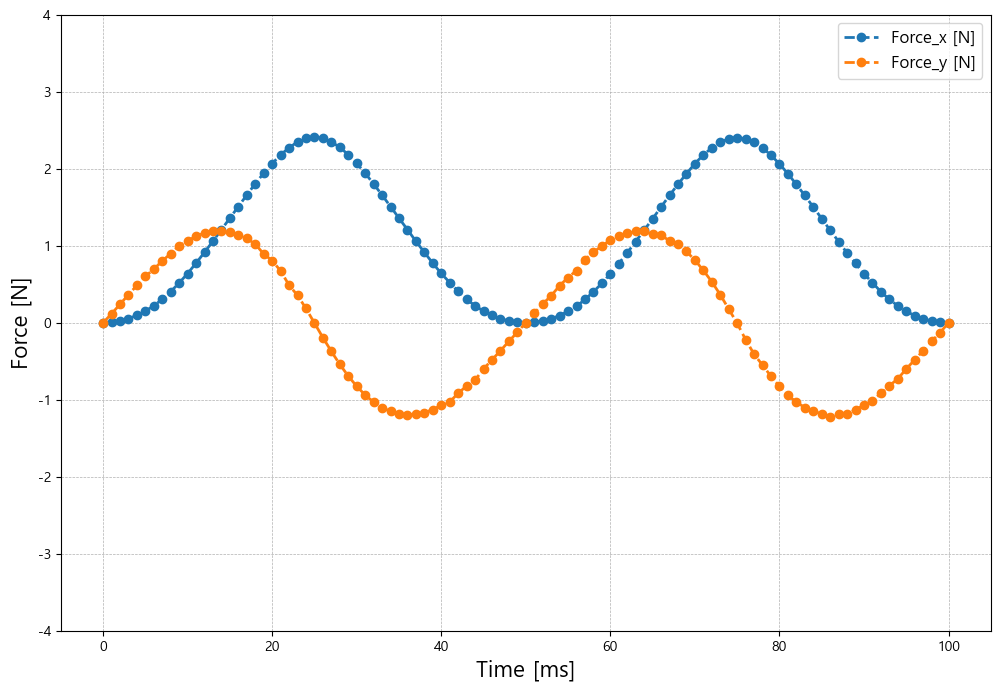

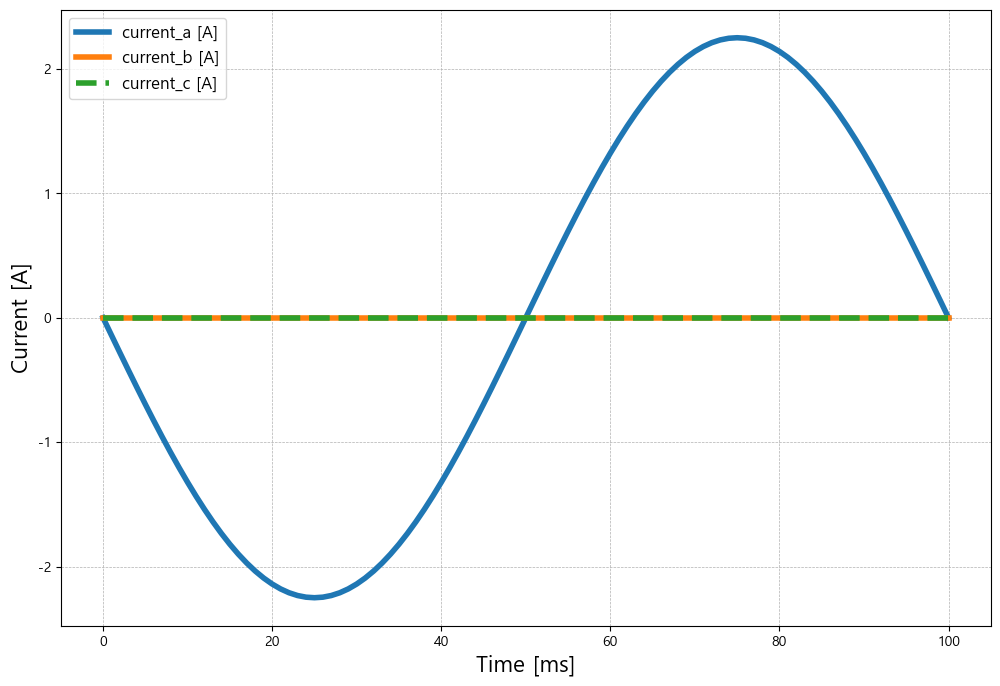

PyAEDT INFO: Python version 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:49:16) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 0.15.0.
PyAEDT INFO: Returning found Desktop session with PID 32028!
PyAEDT INFO: Python version 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:49:16) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 0.15.0.
PyAEDT INFO: Returning found Desktop session with PID 32028!
PyAEDT INFO: No project is defined. Project hw4_5 exists and has been read.
PyAEDT INFO: Added design 'tmp' of type Maxwell 2D.
PyAEDT INFO: Aedt Objects correctly read
PyAEDT INFO: Python version 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:49:16) [MSC v.1929 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 0.15.0.
PyAEDT INFO: Returning found Desktop session with PID 32028!
PyAEDT INFO: No project is defined. Project hw4_5 exists and has been read.
PyAEDT INFO: Active Design set to tmp
PyAEDT INFO: Active Design set to tmp
PyAEDT INFO: 

Exception ignored in: <function AedtObjWrapper.__del__ at 0x0000018121A647C0>
Traceback (most recent call last):
  File "c:\Users\tsne\anaconda3\envs\HARRY\Lib\site-packages\ansys\aedt\core\generic\grpc_plugin_dll_class.py", line 160, in __del__
    def __del__(self):

KeyboardInterrupt: 


PyAEDT WARNING: Error setting up Key Desktop/ActiveDSOConfigurations/Maxwell 2D.
PyAEDT INFO: Design setup Setup1 solved correctly in 0.0h 4.0m 9.0s


AttributeError: 'NoneType' object has no attribute 'CreateReport'

In [20]:



# aedts = get_ansysedt_pids()

# if len(aedts) == 0:
#     commands = [
#     "from ansys.aedt.core import Desktop\nDesktop(new_desktop=True, close_on_exit=False)",
#     "from ansys.aedt.core import Desktop\nDesktop(new_desktop=True, close_on_exit=False)",
#     "from ansys.aedt.core import Desktop\nDesktop(new_desktop=True, close_on_exit=False)",
#     "from ansys.aedt.core import Desktop\nDesktop(new_desktop=True, close_on_exit=False)"
#     ]
#     for code in commands:
#         subprocess.Popen([sys.executable, '-c', code], start_new_session=True)
#     from time import sleep
#     sleep(30)
#     aedts = get_ansysedt_pids()


parmss=[]
parm1 = SimulationParameters()
parm1.update_parameter("veolcity_stator",0)

parm2 = SimulationParameters()
parm2.update_parameter("veolcity_stator",0)
parm2.update_parameter("current_a",0)
parm2.update_parameter("gamma", math.pi * 120/360)
parm2.update_parameter("theta_elec_offset", math.pi / 2 + parm2.gamma)
parm2.update_parameter("current_b",f"{parm2.current_rated}*cos(2*pi*{parm2.freq_elec}*Time + {parm2.theta_elec_offset})")

parm3 = SimulationParameters()
parm3.update_parameter("veolcity_stator",0)
parm3.update_parameter("current_a",0)
parm3.update_parameter("gamma", math.pi * 240/360)
parm3.update_parameter("theta_elec_offset", math.pi / 2 + parm3.gamma)
parm3.update_parameter("current_c",f"{parm3.current_rated}*cos(2*pi*{parm3.freq_elec}*Time + {parm3.theta_elec_offset})")

parm4 = SimulationParameters()
parm4.update_parameter("veolcity_stator",0)

parm4.update_parameter("current_b",f"{parm4.current_rated}*cos(2*pi*{parm4.freq_elec}*Time + {math.pi / 2 + math.pi * 120/360})")
parm4.update_parameter("current_c",f"{parm4.current_rated}*cos(2*pi*{parm2.freq_elec}*Time + {math.pi / 2 + math.pi * 240/360})")

parmss.append(parm1)
parmss.append(parm2)
parmss.append(parm3)
parmss.append(parm4)

hws: List[HW4] =[]
pnames=[f"hw4_{i+5}" for i in range(4)]
csvs_d=["a_only_d.csv", "b_only_d.csv", "c_only_d.csv","abc_d.csv"]
csvs_i=["a_only_i.csv", "b_only_i.csv", "c_only_i.csv","abc_i.csv"]
for i in range(4):
    prm = parmss[i]
    pid = None
    pname=pnames[i]
    hws.append(HW4())
    hws[i].init_to_setup(new_desktop=False,p_name=pname, desi_name=f"{pname}d", simparm=prm, aedt_process_id=33308)
    hws[i].analyze()
    hws[i].plot_data_and_save_csv(csvs_d[i])
    hws[i].plot_current_and_save_csv(csvs_i[i])





# hw4_1 = HW4()

# hw4_1.init_to_setup(new_desktop=False,p_name="test1",desi_name="test2",simparm=parm1,aedt_process_id=4048)
# hw4_1.analyze()
# hw4_1.plot_data_and_save_csv("test1.csv")
# hw4_1.plot_current_and_save_csv("test2.csv")
